In [ ]:
# ============================================================
# STUDENT PERFORMANCE ANALYSIS AND PREDICTION PROJECT
# Member 1: Problem Statement + Dataset Understanding
# File Used: student_performance.csv
# ============================================================
# ------------------------------------------------------------
# Problem Statement
# ------------------------------------------------------------

# PROJECT OBJECTIVE:
#
# The goal of this project is to analyze student academic
# performance using factors like:
#
# 1. Weekly self-study hours
# 2. Attendance percentage
# 3. Class participation
#
# and predict:
#
# 1. Final total score
# 2. Student grade (A, B, C, D, F)
#
# This helps educational institutions identify students
# who may need academic support and improve learning outcomes.


In [12]:
import pandas as pd
import numpy as np
df=pd.read_csv("student_performance.csv")
print(df.head())
print("\n" + "="*60)
print(df.columns)
print("\n" + "="*60)



   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')



In [10]:
print("Data Types:")
print(df.dtypes)
print("\n" + "="*60)
print("Dataset Information:")
print(df.info())

Data Types:
student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB
None


In [13]:
# ------------------------------------------------------------
#Dataset Column Description
# ------------------------------------------------------------

print("\n" + "="*60)
print("DATASET COLUMN DESCRIPTION")
print("="*60)

column_description = {
    "student_id": "Unique identifier for each student",
    
    "weekly_self_study_hours":
    "Average weekly self-study hours (0–40)",
    
    "attendance_percentage":
    "Student attendance percentage (50–100)",
    
    "class_participation":
    "Participation score in class (0–10)",
    
    "total_score":
    "Final performance score (0–100)",
    
    "grade":
    "Final grade category (A, B, C, D, F)"
}

for column, description in column_description.items():
    print(f"{column} --> {description}")



DATASET COLUMN DESCRIPTION
student_id --> Unique identifier for each student
weekly_self_study_hours --> Average weekly self-study hours (0–40)
attendance_percentage --> Student attendance percentage (50–100)
class_participation --> Participation score in class (0–10)
total_score --> Final performance score (0–100)
grade --> Final grade category (A, B, C, D, F)


In [8]:
print("\n" + "="*60)
print("TARGET VARIABLES")
print("="*60)
# Target variables are the columns we want to predict based on the input features
# In this dataset, we have two target variables:
target_variables = ["total_score", "grade"]

print("Target Variables:")
for target in target_variables:
    print("-", target)

# INPUT FEATURES:
#
# These are the columns used to make predictions

print("\n" + "="*60)
print("INPUT FEATURES")
print("="*60)

input_features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

print("Input Features Used for Prediction:")
for feature in input_features:
    print("-", feature)



TARGET VARIABLES
Target Variables:
- total_score
- grade

INPUT FEATURES
Input Features Used for Prediction:
- weekly_self_study_hours
- attendance_percentage
- class_participation


In [17]:
# ============================================================
# Member 2: Data Cleaning + Preprocessing
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [15]:
# We first check if any null values exist

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)

print(df.isnull().sum())



MISSING VALUES CHECK
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64


In [18]:
# ------------------------------------------------------------
#Handle Missing Values (dataset already clean, but this is for practice)
# ------------------------------------------------------------

# If missing values exist:
# Numerical columns -> fill using mean()
# Categorical columns -> fill using mode()

numerical_columns = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]

categorical_columns = ["grade"]

# Fill numerical null values with mean
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical null values with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled successfully")





Missing values handled successfully



DUPLICATE VALUES CHECK
Number of Duplicate Rows: 0
Duplicates removed successfully

OUTLIER DETECTION USING BOXPLOT


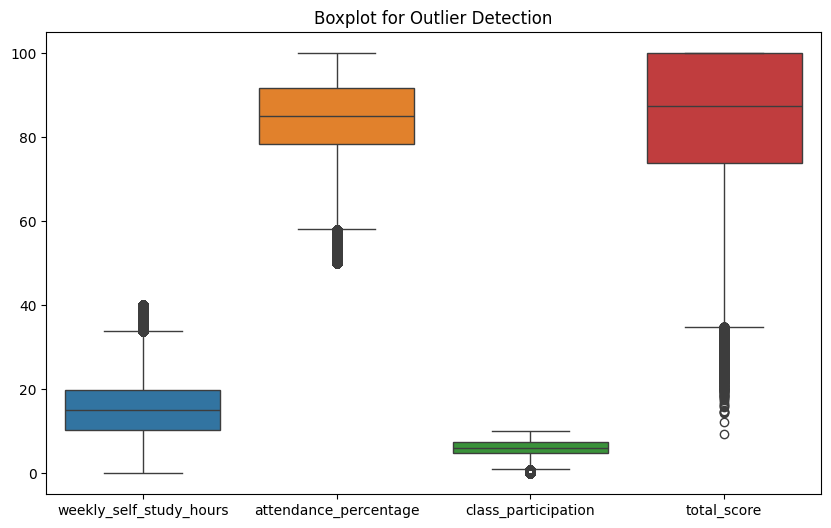

In [19]:
# ------------------------------------------------------------
# Remove Duplicate Rows
# ------------------------------------------------------------

# Duplicate rows create bias and affect model accuracy

print("\n" + "="*60)
print("DUPLICATE VALUES CHECK")
print("="*60)

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

# Remove duplicates if found
df = df.drop_duplicates()

print("Duplicates removed successfully")

# ------------------------------------------------------------
#  Outlier Detection
# ------------------------------------------------------------

# Outliers are unusual values that are too high or too low
# They can affect statistical analysis and model performance

print("\n" + "="*60)
print("OUTLIER DETECTION USING BOXPLOT")
print("="*60)

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "total_score"
    ]
])

plt.title("Boxplot for Outlier Detection")
plt.show()




In [20]:
# ------------------------------------------------------------
# STEP 8: Outlier Handling using IQR Method
# ------------------------------------------------------------

# IQR = Interquartile Range
# Values outside acceptable range are treated as outliers

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    filtered_data = data[
        (data[column] >= lower_limit) &
        (data[column] <= upper_limit)
    ]

    return filtered_data


for col in numerical_columns:
    df = remove_outliers_iqr(df, col)

print("\nOutliers handled using IQR method")


# ------------------------------------------------------------
# Encoding Categorical Values (grade)
# ------------------------------------------------------------

# Machine learning models work better with numbers
# So grade (A, B, C, D, F) must be converted to numeric form

print("\n" + "="*60)
print("LABEL ENCODING FOR GRADE")
print("="*60)

label_encoder = LabelEncoder()

df["grade_encoded"] = label_encoder.fit_transform(df["grade"])

print("Grade Encoding Mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")


# Example:
# A -> 0
# B -> 1
# C -> 2
# D -> 3
# F -> 4





Outliers handled using IQR method

LABEL ENCODING FOR GRADE
Grade Encoding Mapping:
A --> 0
B --> 1
C --> 2
D --> 3
F --> 4


In [22]:
# ------------------------------------------------------------
# Feature Scaling
# ------------------------------------------------------------

# Feature scaling helps when values are in different ranges
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

features_to_scale = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

print("Feature scaling completed successfully")


# ------------------------------------------------------------
# Display Final Cleaned Dataset
# ------------------------------------------------------------

print("\n" + "="*60)
print("FINAL CLEANED DATASET")
print("="*60)

print(df.head())


print("\nDataset Shape After Preprocessing:")
print(df.shape)


# ------------------------------------------------------------
# Save Cleaned Dataset
# ------------------------------------------------------------

df.to_csv("student_performance_cleaned.csv", index=False)

print("\nCleaned dataset saved as:")
print("student_performance_cleaned.csv")


# ------------------------------------------------------------
# STEP 13: Final Conclusion
# ------------------------------------------------------------

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)



FEATURE SCALING
Feature scaling completed successfully

FINAL CLEANED DATASET
   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                 0.519053               1.162852   
1           2                -0.144944              -0.519192   
2           3                 0.666608               0.160095   
3           4                 1.581449              -1.575861   
4           5                -0.233477              -0.314328   

   class_participation  total_score grade  grade_encoded  
0            -1.151864         97.9     A              0  
1            -1.828646         83.9     B              1  
2            -0.370961        100.0     A              0  
3             0.514062        100.0     A              0  
4             0.462002         92.0     A              0  

Dataset Shape After Preprocessing:
(986175, 7)

Cleaned dataset saved as:
student_performance_cleaned.csv

CONCLUSION


In [23]:
# ============================================================
# Member 3: Exploratory Data Analysis (EDA)
# ============================================================
df = pd.read_csv("student_performance_cleaned.csv")
print(df.head())

print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


# ------------------------------------------------------------
# Descriptive Statistics
# ------------------------------------------------------------

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe())

# ------------------------------------------------------------
# Mean, Median, Mode
# ------------------------------------------------------------

print("\n" + "="*60)
print("MEAN, MEDIAN, MODE")
print("="*60)

numerical_columns = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]

for col in numerical_columns:
    print(f"\nColumn: {col}")
    
    mean_value = df[col].mean()
    median_value = df[col].median()
    mode_value = df[col].mode()[0]

    print("Mean   :", mean_value)
    print("Median :", median_value)
    print("Mode   :", mode_value)


# ------------------------------------------------------------
# Variance and Standard Deviation
# ------------------------------------------------------------

print("\n" + "="*60)
print("VARIANCE AND STANDARD DEVIATION")
print("="*60)

for col in numerical_columns:
    print(f"\nColumn: {col}")
    
    variance_value = df[col].var()
    std_value = df[col].std()

    print("Variance           :", variance_value)
    print("Standard Deviation :", std_value)




   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                 0.519053               1.162852   
1           2                -0.144944              -0.519192   
2           3                 0.666608               0.160095   
3           4                 1.581449              -1.575861   
4           5                -0.233477              -0.314328   

   class_participation  total_score grade  grade_encoded  
0            -1.151864         97.9     A              0  
1            -1.828646         83.9     B              1  
2            -0.370961        100.0     A              0  
3             0.514062        100.0     A              0  
4             0.462002         92.0     A              0  
Dataset Shape (Rows, Columns):
(986175, 7)

Column Names:
Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade', 'grade_encoded'],
      dtype='object')

Data Types:
student_id       


DISTRIBUTION ANALYSIS


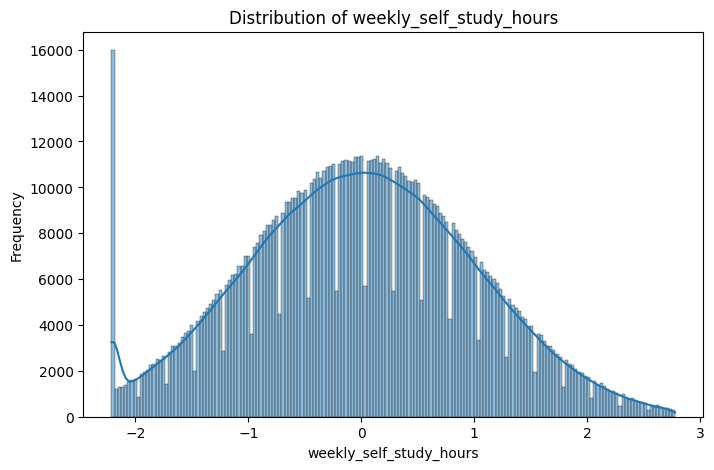

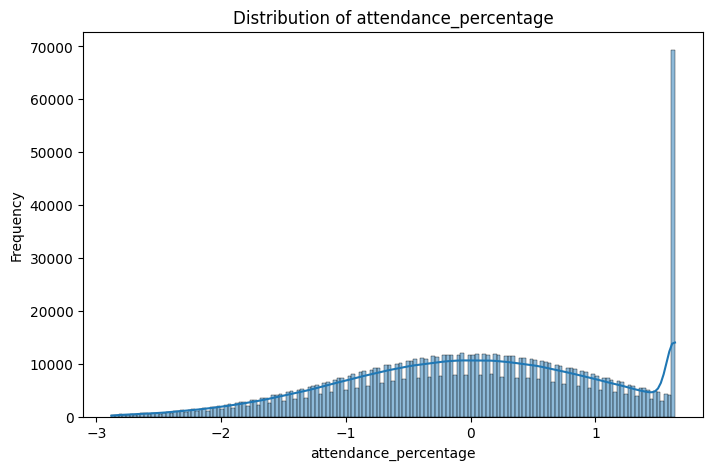

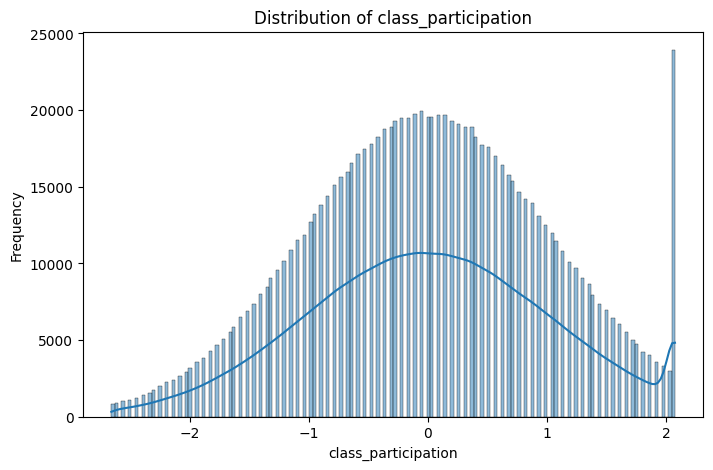

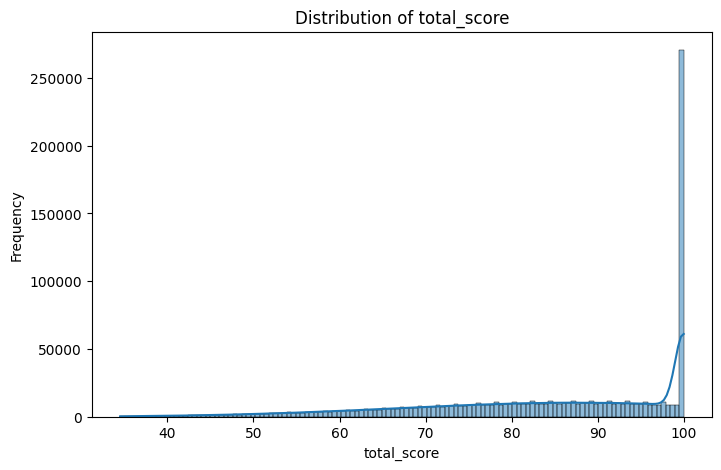


CORRELATION MATRIX
                         weekly_self_study_hours  attendance_percentage  \
weekly_self_study_hours                 1.000000              -0.000971   
attendance_percentage                  -0.000971               1.000000   
class_participation                     0.000738               0.000113   
total_score                             0.815479              -0.000826   
grade_encoded                          -0.746137               0.000734   

                         class_participation  total_score  grade_encoded  
weekly_self_study_hours             0.000738     0.815479      -0.746137  
attendance_percentage               0.000113    -0.000826       0.000734  
class_participation                 1.000000     0.000600      -0.000770  
total_score                         0.000600     1.000000      -0.950575  
grade_encoded                      -0.000770    -0.950575       1.000000  


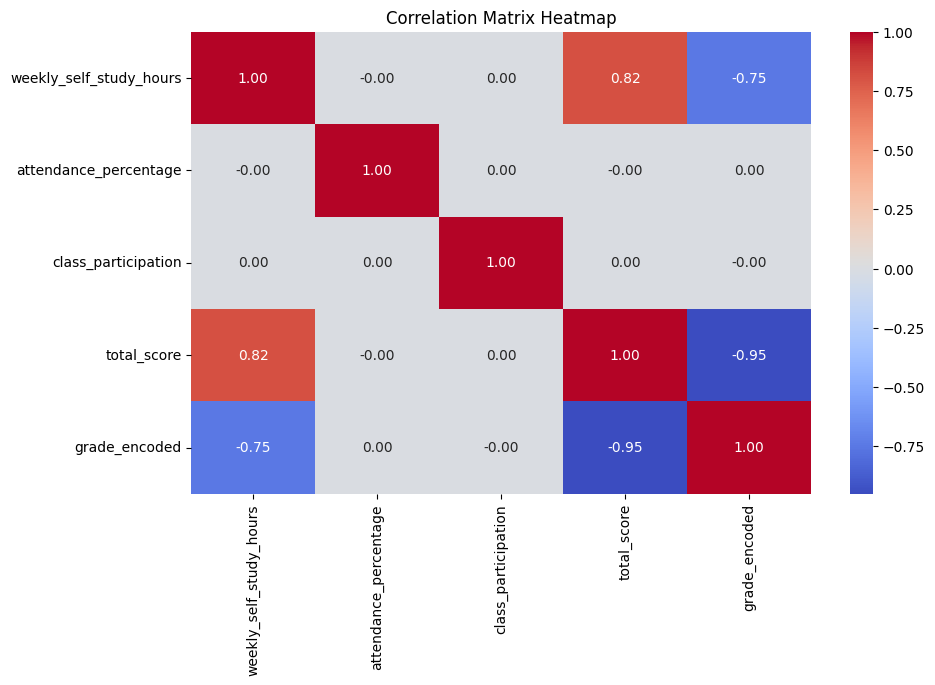

In [24]:
# ------------------------------------------------------------
#  Distribution Analysis using Histograms
# ------------------------------------------------------------

# Histograms help us understand how values are distributed

print("\n" + "="*60)
print("DISTRIBUTION ANALYSIS")
print("="*60)

for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

# Correlation tells how strongly variables are related
#
# Value close to +1 -> strong positive relation
# Value close to -1 -> strong negative relation
# Value close to 0  -> weak/no relation

print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)

correlation_matrix = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "total_score",
        "grade_encoded"
    ]
].corr()

print(correlation_matrix)


# ------------------------------------------------------------
# Heatmap for Correlation Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")
plt.show()




RELATIONSHIP BETWEEN FEATURES


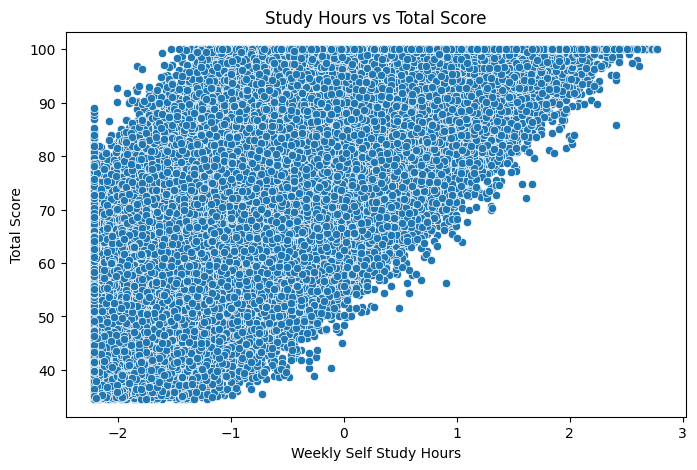

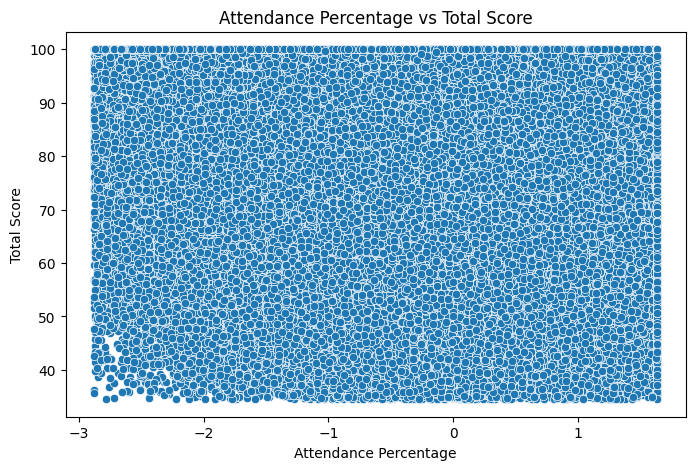

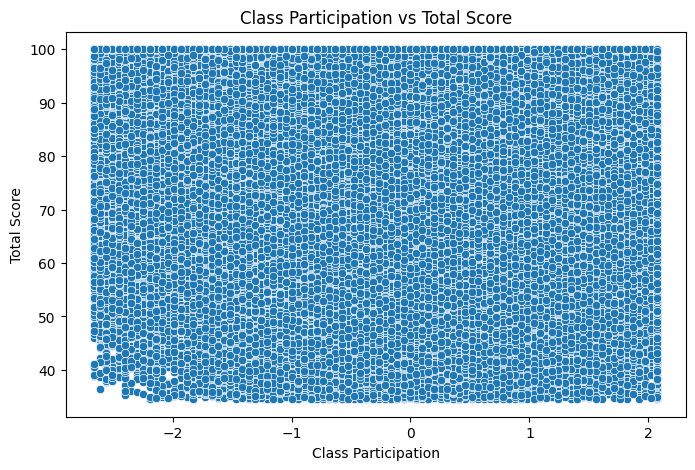

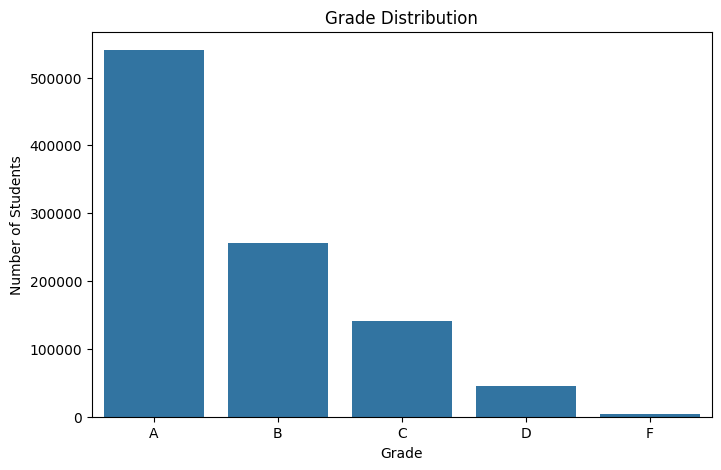


KEY OBSERVATIONS

1. Weekly self-study hours show strong positive
   correlation with total score.

2. Attendance percentage also affects student
   performance but may be less strong than study hours.

3. Class participation contributes positively
   to performance.

4. Grade distribution helps identify overall
   student academic trends.

5. Correlation matrix confirms which features are
   most useful for prediction.



In [ ]:
# ------------------------------------------------------------
# Relationship Between Features
# ------------------------------------------------------------

print("\n" + "="*60)
print("RELATIONSHIP BETWEEN FEATURES")
print("="*60)


# Study Hours vs Total Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="weekly_self_study_hours",
    y="total_score",
    data=df
)

plt.title("Study Hours vs Total Score")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.show()


# Attendance vs Total Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="attendance_percentage",
    y="total_score",
    data=df
)

plt.title("Attendance Percentage vs Total Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Total Score")
plt.show()


# Class Participation vs Total Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="class_participation",
    y="total_score",
    data=df
)

plt.title("Class Participation vs Total Score")
plt.xlabel("Class Participation")
plt.ylabel("Total Score")
plt.show()


# ------------------------------------------------------------
# Grade Distribution
# ------------------------------------------------------------

# Countplot helps show how grades are distributed

plt.figure(figsize=(8, 5))

sns.countplot(
    x="grade",
    data=df,
    order=sorted(df["grade"].unique())
)

plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.show()


# ------------------------------------------------------------
# Key Observations
# ------------------------------------------------------------

print("\n" + "="*60)
print("KEY OBSERVATIONS")
print("="*60)

print("""
1. Weekly self-study hours show strong positive
   correlation with total score.

2. Attendance percentage also affects student
   performance but may be less strong than study hours.

3. Class participation contributes positively
   to performance.

4. Grade distribution helps identify overall
   student academic trends.

5. Correlation matrix confirms which features are
   most useful for prediction.
""")



Linear Regression Model Trained Successfully
Linear Regression Evaluation
MAE  : 7.0824252546390385
RMSE : 8.84850084225237


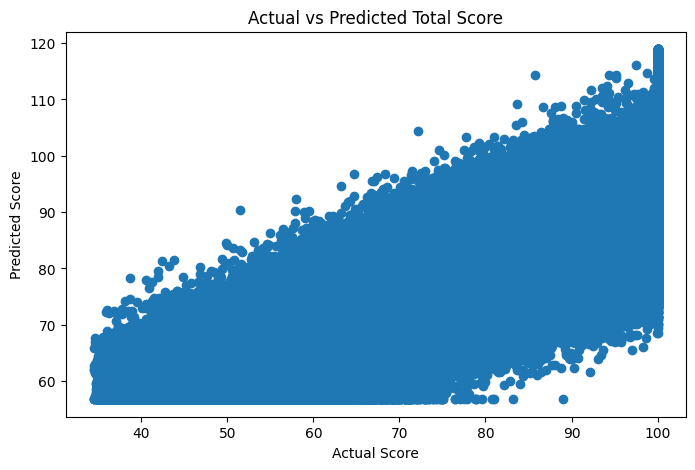

In [ ]:
# ============================================================
# Member 4: Model Building (Core ML Part)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    confusion_matrix)

# Features used for prediction
X = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation"
    ]
]

# Target for regression
y_score = df["total_score"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_score,
    test_size=0.2,
    random_state=42
)

# Create and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("\nLinear Regression Model Trained Successfully")

# Predictions
y_pred = lr_model.predict(X_test)
# ------------------------------------------------------------
# RMSE and MAE
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Linear Regression Evaluation")
print("MAE  :", mae)
print("RMSE :", rmse)


# ------------------------------------------------------------
# Actual vs Predicted Graph
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Total Score")
plt.show()




Logistic Regression Model Trained Successfully

Logistic Regression Accuracy
Accuracy : 0.6958298476436738


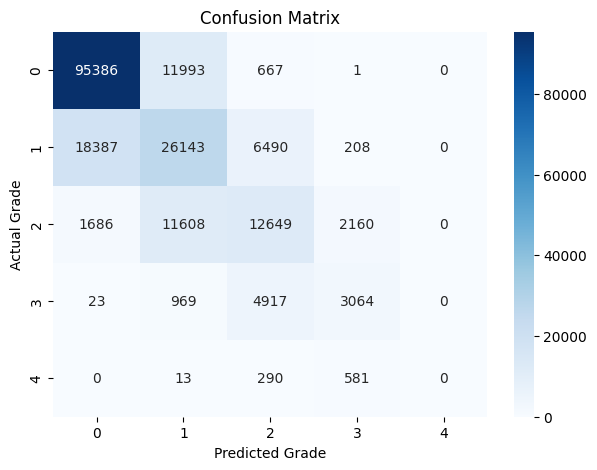


Feature Importance
                   Feature  Coefficient
0  weekly_self_study_hours    12.446653
1    attendance_percentage     0.005423
2      class_participation    -0.003359


In [33]:
# ------------------------------------------------------------
# Logistic Regression (Predict grade)
# ------------------------------------------------------------

# Target for classification
y_grade = df["grade_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_grade,
    test_size=0.2,
    random_state=42
)

# Create and train model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")
grade_pred = log_model.predict(X_test)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, grade_pred)

print("\nLogistic Regression Accuracy")
print("Accuracy :", accuracy)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, grade_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.show()


# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------

# Using coefficients from Linear Regression

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

print("\nFeature Importance")
print(importance)



